In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import random
import string       # I use this to generate random customer IDs

The 2 DCN papers:
* [DCN V2: Improved Deep & Cross Network and Practical Lessons for Web-scale Learning to Rank Systems
Ruoxi Wang, Rakesh Shivanna, Derek Z. Cheng, Sagar Jain, Dong Lin, Lichan Hong, Ed H. Chi](https://arxiv.org/abs/2008.13535)
* Joe go find the first one on Arxiv(2017ish)

In [2]:
# control printing of pandas dataframes:
pd.set_option('display.max_columns', 999)

In [3]:

# simulate some data to use:
# (just random right now - need to redo this for testing the models)
feature_sources = ['customer']*5 + ['product']*3 + ['context']*5 
n_features = len(feature_sources) 

feature_ref = []
for feature_i in range(n_features):
    feature_type = random.choice( ['continuous','binary','categorical'] )
    if feature_sources[feature_i] == 'product': 
        feature_type = random.choice( ['binary','categorical'] )   # product features can only be binary or categorical
    if feature_type == 'continuous':
        bounds = np.random.uniform( low=-1000, high=1000, size=2 )
        feature_ref.append(
                                {
                                    'feature_id':feature_i+1,
                                    'feature_source':feature_sources[feature_i],
                                    'feature_type':'continuous',
                                    'lower_bound':round( min(bounds), 2),
                                    'upper_bound':round( max(bounds), 2),
                                    'feature_name':'X'+str(feature_i+1)+'_'+feature_sources[feature_i]
                                }
        )
    elif feature_type == 'binary':
        feature_ref.append(
                                {
                                    'feature_id':feature_i+1,
                                    'feature_source':feature_sources[feature_i],
                                    'feature_type':'binary',
                                    'feature_name':'X'+str(feature_i+1)+'_'+feature_sources[feature_i]
                                }
        ) 
    else:     # if feature is categorical
        num_categories = random.choice( list(range(3,10)) )
        random_number_vec = np.array( [ random.choice(list(range(1,11))) for i in range(num_categories) ] )
        feature_ref.append(
                                {
                                    'feature_id':feature_i+1,
                                    'feature_source':feature_sources[feature_i],
                                    'feature_type':'categorical',
                                    'possible_categories':random.sample( string.ascii_uppercase, k=num_categories ),
                                    'category_probs':random_number_vec / sum(random_number_vec),
                                    'feature_name':'X'+str(feature_i+1)+'_'+feature_sources[feature_i]
                                }
        )
        
feature_ref    

[{'feature_id': 1,
  'feature_source': 'customer',
  'feature_type': 'categorical',
  'possible_categories': ['Y', 'E', 'A', 'F'],
  'category_probs': array([0.17391304, 0.2173913 , 0.39130435, 0.2173913 ]),
  'feature_name': 'X1_customer'},
 {'feature_id': 2,
  'feature_source': 'customer',
  'feature_type': 'categorical',
  'possible_categories': ['H', 'U', 'S', 'M', 'X', 'Y', 'Z', 'I', 'A'],
  'category_probs': array([0.125     , 0.04166667, 0.125     , 0.125     , 0.02083333,
         0.1875    , 0.02083333, 0.1875    , 0.16666667]),
  'feature_name': 'X2_customer'},
 {'feature_id': 3,
  'feature_source': 'customer',
  'feature_type': 'categorical',
  'possible_categories': ['W', 'A', 'G', 'O', 'T', 'U'],
  'category_probs': array([0.11428571, 0.02857143, 0.14285714, 0.28571429, 0.22857143,
         0.2       ]),
  'feature_name': 'X3_customer'},
 {'feature_id': 4,
  'feature_source': 'customer',
  'feature_type': 'continuous',
  'lower_bound': -537.59,
  'upper_bound': 3.43,
  'fe

In [4]:
# define function that generates a row of features (simulated data): 
def gen_feature_row():
    feature_values = []
    feature_names = []
    for feature_i in range(n_features):
        feature_attributes = feature_ref[feature_i]
        if feature_attributes['feature_type'] == 'continuous':
            feature_values.append( 
                np.random.uniform(
                    low = feature_attributes['lower_bound'],
                    high = feature_attributes['upper_bound'],
                    size = 1
                )[0] 
            )
        elif feature_attributes['feature_type'] == 'binary':
            feature_values.append( random.choice( [0,1] ) )
        else:     # if feature is categorical
            feature_values.append( 
                
                                    np.random.choice(
                                        a = feature_attributes['possible_categories'], 
                                        size = 1,
                                        p = feature_attributes['category_probs'] 
                                    )[0]
                
                                )
        feature_names.append( 'X'+str(feature_attributes['feature_id'])+'_'+feature_attributes['feature_source'] )
    row_df = pd.DataFrame( [feature_values]  )
    row_df.columns = feature_names
    
    return row_df 

gen_feature_row()

,X1_customer,X2_customer,X3_customer,X4_customer,X5_customer,X6_product,X7_product,X8_product,X9_context,X10_context,X11_context,X12_context,X13_context
0,E,Y,O,-170.976594,L,V,L,0,1,-255.311474,F,0,174.213449


simulate some data:

In [5]:
n_customers = 100
n_items_per_person = 3
customer_data_genlist = []

# generate data:
current_customer_id = 0
customer_data_genlist = []
for customer_i in range(n_customers):
    current_customer_id = current_customer_id +1
    for item_j in range(n_items_per_person):
        customer_row_df = gen_feature_row()
        customer_row_df['y'] = np.random.choice( a=[0,1], size=1, p=[0.9, 0.1] )       # random for now
        customer_row_df.index = [current_customer_id]
        customer_data_genlist.append( customer_row_df )
        
customer_data = pd.concat( customer_data_genlist )

customer_data.head(20)

,X1_customer,X2_customer,X3_customer,X4_customer,X5_customer,X6_product,X7_product,X8_product,X9_context,X10_context,X11_context,X12_context,X13_context,y
1,A,Y,T,-26.698364,I,V,A,1,0,-35.584178,A,0,249.391293,0
1,F,Y,W,-349.082333,H,C,A,1,0,-504.222239,L,1,187.592834,0
1,E,S,G,-59.769604,H,C,A,0,1,-247.866594,J,0,385.574792,0
2,A,H,T,-190.213811,Y,K,A,1,0,-322.979240,F,0,212.787699,0
2,F,M,W,-53.441349,H,V,H,1,1,-632.205480,A,0,148.423692,0
2,Y,I,U,-0.270021,I,S,A,1,0,-427.528846,L,1,110.423747,0
3,F,Y,T,-403.163969,H,D,A,1,1,-525.965294,O,0,308.317400,0
3,A,Z,T,-317.325322,H,C,A,0,1,-113.911381,D,1,368.535034,0
3,A,M,U,-139.602604,Y,C,A,1,0,-424.511334,O,1,329.057038,0
4,E,M,T,-128.341159,Y,V,A,1,0,-654.529677,F,1,198.194414,0


give each unique combination of product features a unique product ID:

In [6]:
product_id_ref = customer_data[ customer_data.columns[ customer_data.columns.str.contains('prod') ] ].drop_duplicates().copy().reset_index(drop=True)
available_characters = string.ascii_lowercase+''.join([str(i) for i in range(10)])
def generate_random_product_id():
    return 'prod_'+''.join( random.choice(available_characters) for i in range(10) )

product_id_ref['productID'] = [ generate_random_product_id() for i in range(len(product_id_ref)) ]
product_id_ref

,X6_product,X7_product,X8_product,productID
0,V,A,1,prod_i81dy1zj9a
1,C,A,1,prod_3doqmczdwc
2,C,A,0,prod_8npsciw0f5
3,K,A,1,prod_eae6tbxdsb
4,V,H,1,prod_6gzdnj0olk
5,S,A,1,prod_l3z806jarh
6,D,A,1,prod_duitgn39jp
7,C,H,1,prod_zt3edcep79
8,H,H,1,prod_r3h1yrjphx
9,Y,A,1,prod_syc5awgch2


I want to make the customer IDs into messy strings rather. This is more like how the real data will be:

In [7]:
clean_customer_IDs = customer_data.index.drop_duplicates().tolist()

available_characters = string.ascii_lowercase+''.join([str(i) for i in range(10)])
def generate_random_id():
    return 'cust_'+''.join( random.choice(available_characters) for i in range(10) )

dirty_customer_id_ref = pd.DataFrame(
    {
        'customerID':clean_customer_IDs,
        'alphanumeric_customerID':[ generate_random_id() for i in range(len(clean_customer_IDs)) ]
    }
)    

dirty_customer_id_ref

,customerID,alphanumeric_customerID
0,1,cust_e7ug09x9pl
1,2,cust_edm4vkbss9
2,3,cust_dmakr1isqb
3,4,cust_u1r4qukuxg
4,5,cust_evw9tlft0f
...,...,...
95,96,cust_4nhg32xoi1
96,97,cust_h11209gxqk
97,98,cust_g5rffj2mzc
98,99,cust_g0l6a5mncr


Add the product ID and dirty customer ID fields to the data:

In [8]:
# rather than putting the customer ID in the index, let's put it into a column:
customer_data = customer_data.reset_index()
customer_data = customer_data.rename( columns={'index':'customerID'} )
customer_data = (
    customer_data
    .merge( 
            dirty_customer_id_ref,
            on = 'customerID'
    )
    .merge(
            product_id_ref,
            on = list( customer_data.columns[ customer_data.columns.str.contains('prod') ] )
    )
)    
# put customerID, alphanumeric_customer_ID and productID as first 3 columns:
desired_start_colnames = ['customerID', 'alphanumeric_customerID', 'productID']
desired_following_colnames = list(customer_data.columns)                                     
desired_following_colnames
desired_following_colnames.remove('customerID')
desired_following_colnames.remove('alphanumeric_customerID')
desired_following_colnames.remove('productID')
desired_new_column_order = desired_start_colnames + desired_following_colnames
customer_data = customer_data[ desired_new_column_order ]

customer_data.sort_values(['customerID','productID']).head(10)

,customerID,alphanumeric_customerID,productID,X1_customer,X2_customer,X3_customer,X4_customer,X5_customer,X6_product,X7_product,X8_product,X9_context,X10_context,X11_context,X12_context,X13_context,y
6,1,cust_e7ug09x9pl,prod_3doqmczdwc,F,Y,W,-349.082333,H,C,A,1,0,-504.222239,L,1,187.592834,0
15,1,cust_e7ug09x9pl,prod_8npsciw0f5,E,S,G,-59.769604,H,C,A,0,1,-247.866594,J,0,385.574792,0
0,1,cust_e7ug09x9pl,prod_i81dy1zj9a,A,Y,T,-26.698364,I,V,A,1,0,-35.584178,A,0,249.391293,0
37,2,cust_edm4vkbss9,prod_6gzdnj0olk,F,M,W,-53.441349,H,V,H,1,1,-632.205480,A,0,148.423692,0
24,2,cust_edm4vkbss9,prod_eae6tbxdsb,A,H,T,-190.213811,Y,K,A,1,0,-322.979240,F,0,212.787699,0
40,2,cust_edm4vkbss9,prod_l3z806jarh,Y,I,U,-0.270021,I,S,A,1,0,-427.528846,L,1,110.423747,0
7,3,cust_dmakr1isqb,prod_3doqmczdwc,A,M,U,-139.602604,Y,C,A,1,0,-424.511334,O,1,329.057038,0
16,3,cust_dmakr1isqb,prod_8npsciw0f5,A,Z,T,-317.325322,H,C,A,0,1,-113.911381,D,1,368.535034,0
47,3,cust_dmakr1isqb,prod_duitgn39jp,F,Y,T,-403.163969,H,D,A,1,1,-525.965294,O,0,308.317400,0
1,4,cust_u1r4qukuxg,prod_i81dy1zj9a,E,M,T,-128.341159,Y,V,A,1,0,-654.529677,F,1,198.194414,0


split data into train/validate/test:

In [9]:
# train = 60%
# validate = 20%
# test = 20%

train_mask = np.random.rand( len(customer_data) ) < 0.6
train_data = customer_data[ train_mask ].sort_values('customerID').copy()
non_train_data = customer_data[ ~train_mask ].copy()
valid_mask = np.random.rand(len(non_train_data)) < 0.5
valid_data = non_train_data[ valid_mask ].sort_values('customerID').copy()
test_data = non_train_data[ ~valid_mask ].copy()

print( 
f"""
nrows total data: {len(customer_data)}
nrows training data: {len(train_data)}
nrows validation data: {len(valid_data)}
nrows test data: {len(test_data)}
"""
)


nrows total data: 300
nrows training data: 169
nrows validation data: 51
nrows test data: 80



In [10]:
train_data.head()

,customerID,alphanumeric_customerID,productID,X1_customer,X2_customer,X3_customer,X4_customer,X5_customer,X6_product,X7_product,X8_product,X9_context,X10_context,X11_context,X12_context,X13_context,y
0,1,cust_e7ug09x9pl,prod_i81dy1zj9a,A,Y,T,-26.698364,I,V,A,1,0,-35.584178,A,0,249.391293,0
15,1,cust_e7ug09x9pl,prod_8npsciw0f5,E,S,G,-59.769604,H,C,A,0,1,-247.866594,J,0,385.574792,0
37,2,cust_edm4vkbss9,prod_6gzdnj0olk,F,M,W,-53.441349,H,V,H,1,1,-632.205480,A,0,148.423692,0
40,2,cust_edm4vkbss9,prod_l3z806jarh,Y,I,U,-0.270021,I,S,A,1,0,-427.528846,L,1,110.423747,0
7,3,cust_dmakr1isqb,prod_3doqmczdwc,A,M,U,-139.602604,Y,C,A,1,0,-424.511334,O,1,329.057038,0


In [11]:
feature_types = [ i['feature_type'] for i in feature_ref ]
feature_names = [ i['feature_name'] for i in feature_ref ]
print( f'feature_types: {feature_types}\n' )
print( f'feature_names: {feature_names}\n' )

feature_types: ['categorical', 'categorical', 'categorical', 'continuous', 'categorical', 'categorical', 'categorical', 'binary', 'binary', 'continuous', 'categorical', 'binary', 'continuous']

feature_names: ['X1_customer', 'X2_customer', 'X3_customer', 'X4_customer', 'X5_customer', 'X6_product', 'X7_product', 'X8_product', 'X9_context', 'X10_context', 'X11_context', 'X12_context', 'X13_context']



specify features to be used by model:

In [12]:
BINARY_FEATURE_NAMES = []
CONTINUOUS_FEATURE_NAMES = []
CATEGORICAL_FEATURES_WITH_VOCABULARY = {}
CATEGORICAL_FEATURE_NAMES = []

for feature_i in range(len(feature_names)):
    if feature_types[feature_i]=='continuous':
        CONTINUOUS_FEATURE_NAMES.append( feature_names[feature_i] )
    elif feature_types[feature_i]=='binary':
        BINARY_FEATURE_NAMES.append( feature_names[feature_i] )
    elif feature_types[feature_i]=='categorical':   # else feature must be categorical
        CATEGORICAL_FEATURE_NAMES.append( feature_names[feature_i] ) 
        CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_names[feature_i]] = list( customer_data[feature_names[feature_i]].unique() )
    else:
        print( f'ERROR: {feature_names[feature_i]}' )

FEATURES_WITH_EMBEDDING_DIMENSION = {           
    # format is 'feature_name': dimension of embedding
    'alphanumeric_customerID': 6,
    'productID': 6
}    
EMBED_FEATURES_WITH_VOCABULARY = {
    'alphanumeric_customerID': list( customer_data['alphanumeric_customerID'].unique() ),
    'productID': list( customer_data['productID'].unique() )
}
        
NUMERIC_FEATURE_NAMES = BINARY_FEATURE_NAMES + CONTINUOUS_FEATURE_NAMES
TO_EMBED_FEATURE_NAMES = list( FEATURES_WITH_EMBEDDING_DIMENSION.keys() )

print( f'NUMERIC_FEATURE_NAMES: {NUMERIC_FEATURE_NAMES}' )
print( f'CATEGORICAL_FEATURES_WITH_VOCABULARY: {CATEGORICAL_FEATURES_WITH_VOCABULARY}' )
print( f'FEATURES_WITH_EMBEDDING_DIMENSION: {FEATURES_WITH_EMBEDDING_DIMENSION}')

NUMERIC_FEATURE_NAMES: ['X8_product', 'X9_context', 'X12_context', 'X4_customer', 'X10_context', 'X13_context']
CATEGORICAL_FEATURES_WITH_VOCABULARY: {'X1_customer': ['A', 'E', 'Y', 'F'], 'X2_customer': ['Y', 'M', 'H', 'I', 'A', 'Z', 'S', 'U', 'X'], 'X3_customer': ['T', 'G', 'O', 'W', 'U', 'A'], 'X5_customer': ['I', 'Y', 'L', 'X', 'H', 'N', 'T'], 'X6_product': ['V', 'C', 'K', 'S', 'D', 'H', 'Y', 'Q', 'E'], 'X7_product': ['A', 'H', 'L'], 'X11_context': ['A', 'F', 'D', 'J', 'L', 'O', 'T', 'M']}
FEATURES_WITH_EMBEDDING_DIMENSION: {'alphanumeric_customerID': 6, 'productID': 6}


In [13]:
ALL_FEATURE_NAMES = NUMERIC_FEATURE_NAMES + CATEGORICAL_FEATURE_NAMES + TO_EMBED_FEATURE_NAMES
print( f'CONTINUOUS_FEATURE_NAMES: {CONTINUOUS_FEATURE_NAMES}')
print( f'BINARY_FEATURE_NAMES: {BINARY_FEATURE_NAMES}')
print( f'NUMERIC_FEATURE_NAMES: {NUMERIC_FEATURE_NAMES}')
print( f'CATEGORICAL_FEATURE_NAMES: {CATEGORICAL_FEATURE_NAMES}')
print( f'TO_EMBED_FEATURE_NAMES: {TO_EMBED_FEATURE_NAMES}')
print( f'ALL_FEATURE_NAMES: {ALL_FEATURE_NAMES}' )

CONTINUOUS_FEATURE_NAMES: ['X4_customer', 'X10_context', 'X13_context']
BINARY_FEATURE_NAMES: ['X8_product', 'X9_context', 'X12_context']
NUMERIC_FEATURE_NAMES: ['X8_product', 'X9_context', 'X12_context', 'X4_customer', 'X10_context', 'X13_context']
CATEGORICAL_FEATURE_NAMES: ['X1_customer', 'X2_customer', 'X3_customer', 'X5_customer', 'X6_product', 'X7_product', 'X11_context']
TO_EMBED_FEATURE_NAMES: ['alphanumeric_customerID', 'productID']
ALL_FEATURE_NAMES: ['X8_product', 'X9_context', 'X12_context', 'X4_customer', 'X10_context', 'X13_context', 'X1_customer', 'X2_customer', 'X3_customer', 'X5_customer', 'X6_product', 'X7_product', 'X11_context', 'alphanumeric_customerID', 'productID']


normalize the continuous features:

In [14]:
print( '\nnumeric column means before standardisation:' )
print( ' training set:')
print( train_data[ CONTINUOUS_FEATURE_NAMES ].mean() )
print( ' validation set:')
print( valid_data[ CONTINUOUS_FEATURE_NAMES ].mean() )
print( ' test set:')
print( test_data[ CONTINUOUS_FEATURE_NAMES ].mean() )

print( '\nnumeric column standard deviations before standardisation:' )
print( ' training set:')
print( train_data[ CONTINUOUS_FEATURE_NAMES ].std() )
print( ' validation set:')
print( valid_data[ CONTINUOUS_FEATURE_NAMES ].std() )
print( ' test set:')
print( test_data[ CONTINUOUS_FEATURE_NAMES ].std() )

numeric_col_means_traindata = {}
numeric_col_std_devs_traindata = {}
for colname_j in CONTINUOUS_FEATURE_NAMES:
    numeric_col_means_traindata[colname_j] = train_data[colname_j].mean()  
    numeric_col_std_devs_traindata[colname_j] = train_data[colname_j].std()
    # standardise the data:
    train_data[colname_j] = (
        ( train_data[colname_j] - numeric_col_means_traindata[colname_j] ) /
        numeric_col_std_devs_traindata[colname_j]
    )
    valid_data[colname_j] = (
        ( valid_data[colname_j] - numeric_col_means_traindata[colname_j] ) /
        numeric_col_std_devs_traindata[colname_j]
    )
    test_data[colname_j] = (
        ( test_data[colname_j] - numeric_col_means_traindata[colname_j] ) /
        numeric_col_std_devs_traindata[colname_j]
    )
        
print( '\nnumeric column means after standardisation:' )
print( ' training set:')
print( train_data[ CONTINUOUS_FEATURE_NAMES ].mean() )
print( ' validation set:')
print( valid_data[ CONTINUOUS_FEATURE_NAMES ].mean() )
print( ' test set:')
print( test_data[ CONTINUOUS_FEATURE_NAMES ].mean() )

print( '\nnumeric column standard deviations after standardisation:' )
print( ' training set:')
print( train_data[ CONTINUOUS_FEATURE_NAMES ].std() )
print( ' validation set:')
print( valid_data[ CONTINUOUS_FEATURE_NAMES ].std() )
print( ' test set:')
print( test_data[ CONTINUOUS_FEATURE_NAMES ].std() )


numeric column means before standardisation:
 training set:
X4_customer   -270.133975
X10_context   -324.293306
X13_context    250.907277
dtype: float64
 validation set:
X4_customer   -277.837493
X10_context   -372.703368
X13_context    238.580639
dtype: float64
 test set:
X4_customer   -254.278732
X10_context   -316.887362
X13_context    267.847792
dtype: float64

numeric column standard deviations before standardisation:
 training set:
X4_customer    167.751771
X10_context    189.481246
X13_context    118.053746
dtype: float64
 validation set:
X4_customer    155.818261
X10_context    171.448627
X13_context    123.312476
dtype: float64
 test set:
X4_customer    155.590516
X10_context    191.623896
X13_context    109.234149
dtype: float64

numeric column means after standardisation:
 training set:
X4_customer    6.175205e-17
X10_context    1.602926e-16
X13_context    1.379567e-16
dtype: float64
 validation set:
X4_customer   -0.045922
X10_context   -0.255487
X13_context   -0.104415
dt

# Deep & Cross Network

In [15]:
def dataframe_to_dataset(dataframe, shuffle=False):
    # function which converts a pandas dataframe into a tensorflow data format
    dataframe = dataframe.copy()
    labels = dataframe.pop('y')    # pull out y (response) column 
    ds = tf.data.Dataset.from_tensor_slices( (dict(dataframe), labels) )
    if shuffle==True:
        ds = ds.shuffle( buffer_size=len(dataframe) )
    return ds

train_ds = dataframe_to_dataset( train_data, shuffle=True )
valid_ds = dataframe_to_dataset( valid_data, shuffle=True )
test_ds = dataframe_to_dataset( test_data, shuffle=False )

# batch the datasets:
train_ds = train_ds.batch(32)
valid_ds = valid_ds.batch(32)
test_set = test_ds.batch(32)

In [16]:
def create_model_inputs():
    inputs = {}
    for feature_name in ALL_FEATURE_NAMES:
        if feature_name in CONTINUOUS_FEATURE_NAMES:
            inputs[feature_name] = layers.Input(
                name=feature_name, shape=(), dtype=tf.float32
            )
        elif feature_name in BINARY_FEATURE_NAMES:
            inputs[feature_name] = layers.Input(
                name=feature_name, shape=(), dtype=tf.float32   
            )
        elif (feature_name in CATEGORICAL_FEATURE_NAMES) or (feature_name in TO_EMBED_FEATURE_NAMES):
            inputs[feature_name] = layers.Input(
                name=feature_name, shape=(), dtype=tf.string
            )            
        else:
            print( f'ERROR: {feature_name}' )
    return inputs

In [17]:
from tensorflow.keras.layers.experimental.preprocessing import CategoryEncoding
from tensorflow.keras.layers.experimental.preprocessing import StringLookup

def encode_inputs( inputs, input_layer_name=None ):
    encoded_features = []
    for feature_name in inputs:
        if feature_name in CATEGORICAL_FEATURE_NAMES:
            vocabulary = CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name]
            # Create a lookup to convert string values to an integer index.
            # Since we are not using a mask token nor expecting any out of vocabulary
            # (oov) token, we set mask_token to None and  num_oov_indices to 0.
            index = StringLookup(
                    vocabulary = vocabulary, 
                    mask_token = None, 
                    num_oov_indices = 0
            )
            # Convert the string input values into integer indices.
            value_index = index( inputs[feature_name] )
            # Create a one-hot encoder.
            onehot_encoder = CategoryEncoding(output_mode="binary")
            onehot_encoder.adapt( index(vocabulary) )
            # Convert the index values to a one-hot representation.
            encoded_feature = onehot_encoder(value_index)            
        elif feature_name in TO_EMBED_FEATURE_NAMES:
            vocabulary = EMBED_FEATURES_WITH_VOCABULARY[feature_name]
            # Create a lookup to convert string values to an integer index.
            # Since we are not using a mask token nor expecting any out of vocabulary
            # (oov) token, we set mask_token to None and num_oov_indices to 0.
            index = StringLookup(
                    vocabulary = vocabulary, 
                    mask_token = None, 
                    num_oov_indices = 0
            )
            # Convert the string input values into integer indices.
            value_index = index( inputs[feature_name] )
            embedding_dim = int( FEATURES_WITH_EMBEDDING_DIMENSION[feature_name] )
            # Create an embedding layer with the specified dimensions.
            embedding_encoder = layers.Embedding(
                    input_dim = len(vocabulary),
                   output_dim = embedding_dim
                )
            # Convert the index values to embedding representations.
            encoded_feature = embedding_encoder(value_index)
        else:
            # Use the numerical feature as-is.
            encoded_feature = tf.expand_dims(inputs[feature_name], -1)

        encoded_features.append(encoded_feature)
    
    if input_layer_name is not None:
        all_features = layers.concatenate( encoded_features, name=input_layer_name )
    else:
        all_features = layers.concatenate( encoded_features )
    
    return all_features

In [18]:
inputs = create_model_inputs()
input_features = encode_inputs( inputs, input_layer_name='all_features' )

In [19]:
CONTINUOUS_FEATURE_NAMES

['X4_customer', 'X10_context', 'X13_context']

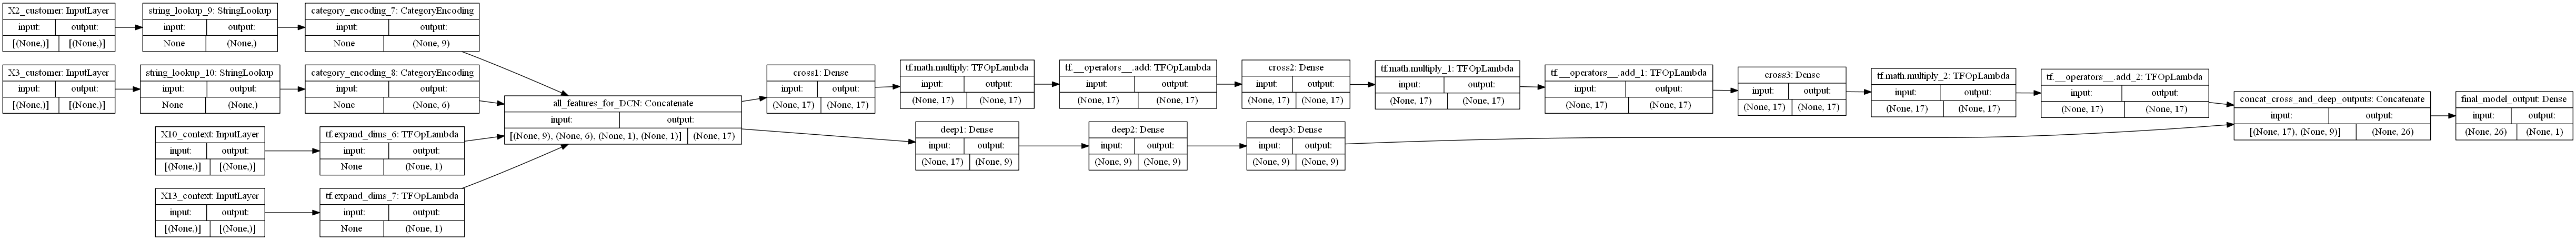

In [20]:
#################################
# Parallel Deep & Cross Network #
#################################
inputs_for_deep_and_cross = inputs
inputs_for_deep_and_cross = { x: inputs[x] for x in ['X2_customer', 'X3_customer', 'X10_context', 'X13_context'] }

# x0 is the input layer:
x0 = encode_inputs( 
                    inputs_for_deep_and_cross, 
                    input_layer_name='all_features_for_DCN'
                  )

# cross part ---------------------------------------
x1 = ( layers.Dense( x0.shape[-1], activation=None, name='cross1' )(x0) * x0 ) + x0
x2 = ( layers.Dense( x1.shape[-1], activation=None, name='cross2' )(x1) * x0 ) + x1
x3 = ( layers.Dense( x2.shape[-1], activation=None, name='cross3' )(x2) * x0 ) + x2
cross_output = x3 

# deep part ----------------------------------------
deep_layer1 = layers.Dense( 
                            9, 
                            activation='relu',
                            name = 'deep1' 
                          )(x0)
deep_layer2 = layers.Dense( 
                            9, 
                            activation='relu',
                            name = 'deep2'
                          )(deep_layer1)
deep_output = layers.Dense( 
                            9, 
                            activation='sigmoid',
                            name = 'deep3'
                          )(deep_layer2)

combine_model_outputs = layers.concatenate( 
    [ 
        cross_output,
        deep_output,
    ],
    name = 'concat_cross_and_deep_outputs'
)

final_output = layers.Dense( 
                             1, 
                             activation='sigmoid',
                             name = 'final_model_output'
                           )(combine_model_outputs)

model = keras.Model( 
                     inputs_for_deep_and_cross,
                     final_output
                   )

keras.utils.plot_model( model, show_shapes=True, rankdir="LR" )

In [21]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
X2_customer (InputLayer)        [(None,)]            0                                            
__________________________________________________________________________________________________
X3_customer (InputLayer)        [(None,)]            0                                            
__________________________________________________________________________________________________
string_lookup_9 (StringLookup)  (None,)              0           X2_customer[0][0]                
__________________________________________________________________________________________________
string_lookup_10 (StringLookup) (None,)              0           X3_customer[0][0]                
______________________________________________________________________________________________

In [24]:
model.compile("adam", "binary_crossentropy", metrics=["accuracy"])

model.fit( 
           train_ds,
           epochs = 20,
           validation_data = valid_ds
         )

Epoch 1/20


C:\Program Files (x86)\Microsoft Visual Studio\Shared\Python37_64\lib\site-packages\tensorflow\python\keras\engine\functional.py:595: UserWarning: Input dict contained keys ['customerID'] which did not match any model input. They will be ignored by the model.
  [n for n in tensors.keys() if n not in ref_input_names])


6/6 [==============================] - 2s 108ms/step - loss: 0.6689 - accuracy: 0.6782 - val_loss: 0.6382 - val_accuracy: 0.8235
Epoch 2/20
6/6 [==============================] - 0s 15ms/step - loss: 0.6297 - accuracy: 0.8438 - val_loss: 0.6126 - val_accuracy: 0.8235
Epoch 3/20
6/6 [==============================] - 0s 17ms/step - loss: 0.6006 - accuracy: 0.8735 - val_loss: 0.5889 - val_accuracy: 0.8235
Epoch 4/20
6/6 [==============================] - 0s 17ms/step - loss: 0.5521 - accuracy: 0.9111 - val_loss: 0.5659 - val_accuracy: 0.8235
Epoch 5/20
6/6 [==============================] - 0s 16ms/step - loss: 0.5149 - accuracy: 0.9045 - val_loss: 0.5454 - val_accuracy: 0.8235
Epoch 6/20
6/6 [==============================] - ETA: 0s - loss: 0.5165 - accuracy: 0.87 - 0s 17ms/step - loss: 0.4956 - accuracy: 0.8843 - val_loss: 0.5285 - val_accuracy: 0.8235
Epoch 7/20
6/6 [==============================] - 0s 18ms/step - loss: 0.4549 - accuracy: 0.8940 - val_loss: 0.5141 - val_accuracy: 0.

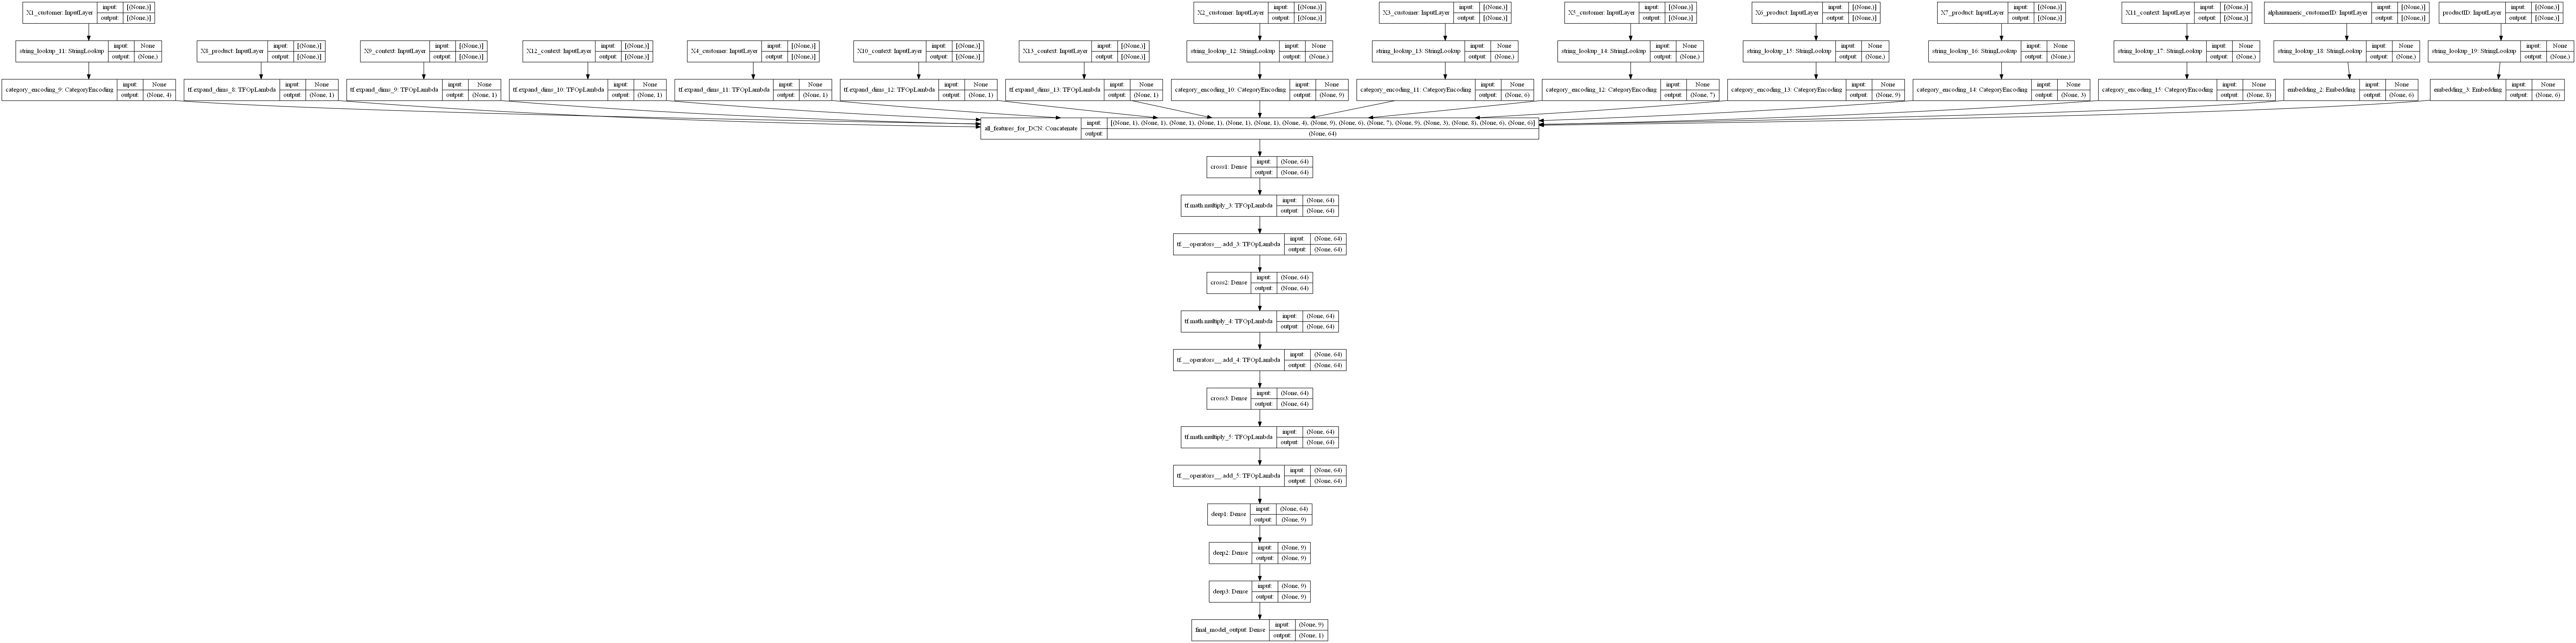

In [23]:
###################################
# Stacked Deep & Cross Network #
###################################
inputs_for_deep_and_cross = inputs
#inputs_for_deep_and_cross = { x: inputs[x] for x in ['X2_customer', 'X3_customer', 'X10_context', 'X13_context'] }

# x0 is the input layer:
x0 = encode_inputs( 
                    inputs_for_deep_and_cross, 
                    input_layer_name='all_features_for_DCN'
                  )

# cross part ---------------------------------------
x1 = ( layers.Dense( x0.shape[-1], activation=None, name='cross1' )(x0) * x0 ) + x0
x2 = ( layers.Dense( x1.shape[-1], activation=None, name='cross2' )(x1) * x0 ) + x1
x3 = ( layers.Dense( x2.shape[-1], activation=None, name='cross3' )(x2) * x0 ) + x2
cross_output = x3 

# deep part ----------------------------------------
deep_layer1 = layers.Dense( 
                            9, 
                            activation='relu',
                            name = 'deep1' 
                          )(cross_output)
deep_layer2 = layers.Dense( 
                            9, 
                            activation='relu',
                            name = 'deep2'
                          )(deep_layer1)
deep_output = layers.Dense( 
                            9, 
                            activation='sigmoid',
                            name = 'deep3'
                          )(deep_layer2)

final_output = layers.Dense( 
                             1, 
                             activation='sigmoid',
                             name = 'final_model_output'
                           )(deep_output)

model = keras.Model( 
                     inputs_for_deep_and_cross,
                     final_output
                   )

keras.utils.plot_model( model, show_shapes=True, rankdir="TB" )